# SIP Week 1 — Signal Diagnostics

This notebook demonstrates:
- Loading an audio signal
- Framing the signal
- Computing frame-level statistics
- Inspecting stability across time

In [1]:
import sys
print("Python executable:", sys.executable)

Python executable: /opt/miniconda3/envs/sip/bin/python


## Import Required Libraries

We import numerical and signal processing libraries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from IPython.display import Audio

## Load a Sample Audio File

We load an example audio signal to analyze.

In [3]:
y, sr = librosa.load(librosa.ex('trumpet'))

print("Sampling rate:", sr)
print("Signal length:", len(y))

Sampling rate: 22050
Signal length: 117601


## Listen to the Signal

In [4]:
Audio(y, rate=sr)

## Waveform Visualization

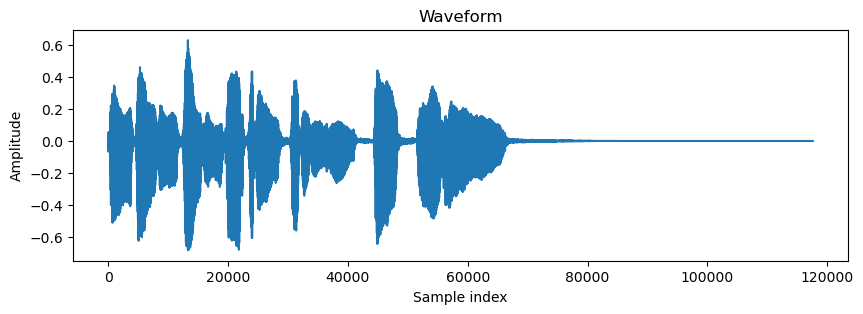

In [5]:
plt.figure(figsize=(10, 3))
plt.plot(y)
plt.title("Waveform")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.show()

## 1. Signal Description

- Audio source: librosa example (trumpet)
- Sampling rate: 22050 Hz
- Duration: computed below

In [6]:
duration = len(y) / sr
print("Duration (seconds):", duration)

Duration (seconds): 5.333378684807256


## 2. Framing Setup

We use:
- Frame length: 25 ms
- Hop size: 10 ms

These values approximate short-time stationarity.

In [7]:
# Frame parameters (ms → samples)
frame_ms = 25
hop_ms = 10

frame_length = int(sr * frame_ms / 1000)
hop_length = int(sr * hop_ms / 1000)

print("Frame length (samples):", frame_length)
print("Hop length (samples):", hop_length)

# Create frames
frames = librosa.util.frame(y, frame_length=frame_length, hop_length=hop_length)

print("Frame matrix shape:", frames.shape)

Frame length (samples): 551
Hop length (samples): 220
Frame matrix shape: (551, 533)


## 3. Statistical Checks

We compute frame-level mean and variance, visualize variance over time, and compute a simple stability ratio:

r = (max variance) / (min variance)

Number of frames: 533
Mean (first 5): [ 0.00161723 -0.00160866 -0.00139931  0.00023216  0.00172858]
Variance (first 5): [0.00690197 0.01663073 0.02440173 0.02765297 0.02689833]


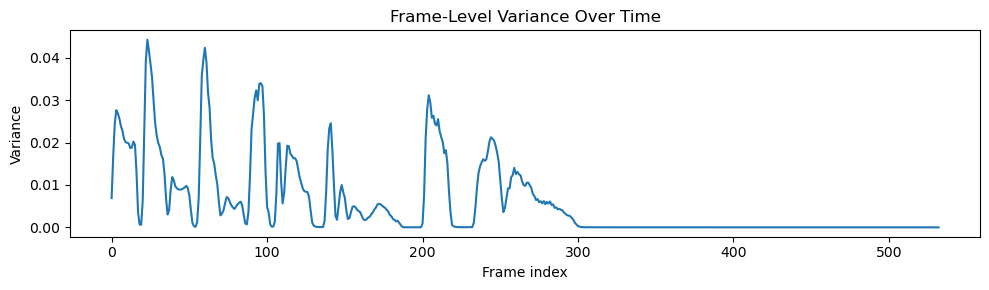

Variance ratio r = max/min: 156345184.0


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Frame-level statistics (one value per frame)
frame_means = np.mean(frames, axis=0)
frame_vars  = np.var(frames, axis=0)

print("Number of frames:", len(frame_means))
print("Mean (first 5):", frame_means[:5])
print("Variance (first 5):", frame_vars[:5])

# Plot variance over time (frame index)
plt.figure(figsize=(10, 3))
plt.plot(frame_vars)
plt.title("Frame-Level Variance Over Time")
plt.xlabel("Frame index")
plt.ylabel("Variance")
plt.tight_layout()
plt.show()

# Variance ratio across frames
r = float(np.max(frame_vars) / (np.min(frame_vars) + 1e-12))
print("Variance ratio r = max/min:", r)

> Note: A naïve max/min ratio is unstable because silence frames distort the denominator. We must design robust diagnostics.

In [9]:
# Robust variance ratio using percentiles
low = np.percentile(frame_vars, 5)
high = np.percentile(frame_vars, 95)

r_robust = high / (low + 1e-12)

print("Robust variance ratio (95/5):", r_robust)

Robust variance ratio (95/5): 49224372.0


In [10]:
print("Min variance:", np.min(frame_vars))
print("5th percentile:", np.percentile(frame_vars, 5))
print("Median:", np.median(frame_vars))
print("Max variance:", np.max(frame_vars))

Min variance: 2.8218977e-10
5th percentile: 5.2178123e-10
Median: 0.00024329724
Max variance: 0.04427536


> Note: The signal is strongly non-stationary across the whole recording. Even the 5th percentile is still near silence: 5.2e-10 because many frames are almost silent.

In [11]:
# Use median-based normalization threshold
active_threshold = np.median(frame_vars) * 0.1

active_frames = frame_vars[frame_vars > active_threshold]

r_active = np.max(active_frames) / np.min(active_frames)

print("Variance ratio (active frames only):", r_active)

Variance ratio (active frames only): 1697.5345


> **Note:**
>
> Statistical diagnostics depend on how we define the population.
> Silence frames should not be treated the same as voiced frames.
>
> The simple rule `r ≤ 2` is not intended for raw waveform variance
> across an entire recording containing silence.
>
> For speech, stability is typically assessed on:
> - A voiced segment (not silence)
> - A feature domain (e.g., log-power or spectral bands), not raw waveform samples
> - A short time window or controlled utterance type

A better “simple stationarity check” for Week 1 (code)

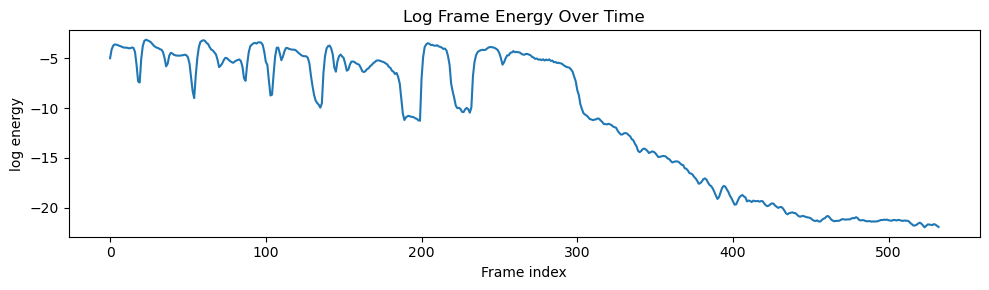

Robust log-energy range (95-5 percentile): 17.71191


In [12]:
# Frame energy (per frame)
frame_energy = np.mean(frames**2, axis=0)
log_energy = np.log(frame_energy + 1e-12)

plt.figure(figsize=(10, 3))
plt.plot(log_energy)
plt.title("Log Frame Energy Over Time")
plt.xlabel("Frame index")
plt.ylabel("log energy")
plt.tight_layout()
plt.show()

# Robust range (95th - 5th percentile) as a stability summary
range_robust = np.percentile(log_energy, 95) - np.percentile(log_energy, 5)
print("Robust log-energy range (95-5 percentile):", range_robust)

## 4. Decision

Rule (heuristic default):

- If r ≤ 2: acceptable stability
- If r > 2: consider shortening the frame or applying normalization

In [13]:
threshold = 2.0

if r <= threshold:
    decision = "PASS"
    action = "Keep default frame/hop."
else:
    decision = "FAIL"
    action = "Consider shortening frame length and/or applying normalization (e.g., CMVN)."

print("Decision:", decision)
print("Action:", action)

Decision: FAIL
Action: Consider shortening frame length and/or applying normalization (e.g., CMVN).


## 5. Outputs

We save frame-level statistics to a CSV file for traceability.

In [14]:
df = pd.DataFrame({
    "frame_index": np.arange(len(frame_means)),
    "frame_mean": frame_means,
    "frame_variance": frame_vars
})

csv_path = "week1_frame_stats.csv"
df.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)

df.head()

Saved CSV: week1_frame_stats.csv


,frame_index,frame_mean,frame_variance
0,0,0.001617,0.006902
1,1,-0.001609,0.016631
2,2,-0.001399,0.024402
3,3,0.000232,0.027653
4,4,0.001729,0.026898


Optional (recommended): Save the variance plot as an image

In [15]:
plot_path = "week1_frame_variance.png"
plt.figure(figsize=(10, 3))
plt.plot(frame_vars)
plt.title("Frame-Level Variance Over Time")
plt.xlabel("Frame index")
plt.ylabel("Variance")
plt.tight_layout()
plt.savefig(plot_path, dpi=150)
plt.close()
print("Saved plot:", plot_path)

Saved plot: week1_frame_variance.png
